In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
dataframe = pd.read_csv("diabetes.csv")
dataframe.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
dataframe.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Missing Values in a given dataset

In [6]:
dataframe.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
dataframe.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Data Imputation of 0's in every feature

Size of the data

In [8]:
dataframe.shape

(768, 9)

Target column : Outcome[0,1] (Binary Classification Task)

As the target column is available in the dataset , supervised machine learning algorithm 

Records: 768

In [9]:
dataframe.corr().T

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


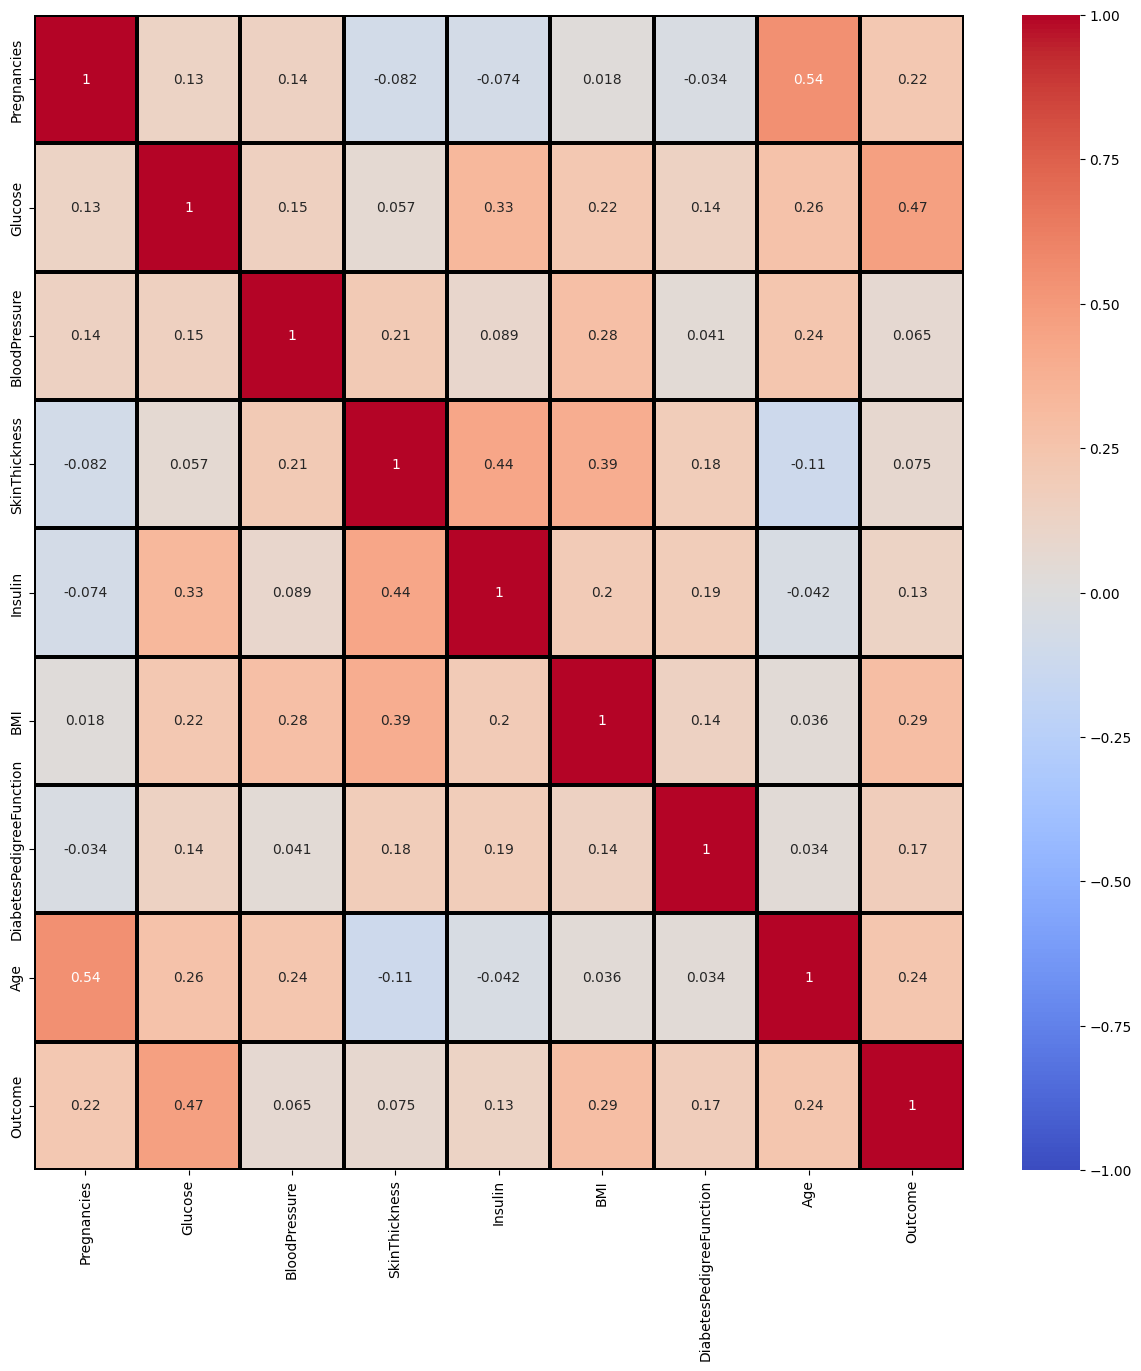

In [10]:
plt.figure(figsize=(15,15))
ax = sns.heatmap(dataframe.corr(), annot=True, cmap="coolwarm", linewidths=1.5, linecolor="black", vmin=-1, vmax=1)
plt.savefig("correlation_heatmap.png")
plt.show()


Descriptive Statistics of the given data

In [61]:
dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,4.278646,3.021516,1.000,2.00000,3.0000,6.00000,17.00
Glucose,768.0,121.681605,30.436016,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,27.334635,9.229014,7.000,23.00000,23.0000,32.00000,99.00
Insulin,768.0,94.652344,105.547598,14.000,30.50000,31.2500,127.25000,846.00
BMI,768.0,32.450805,6.875374,18.200,27.50000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Data Imputation

C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\3906307463.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( dataframe["Pregnancies"])


<Axes: xlabel='Pregnancies', ylabel='Density'>

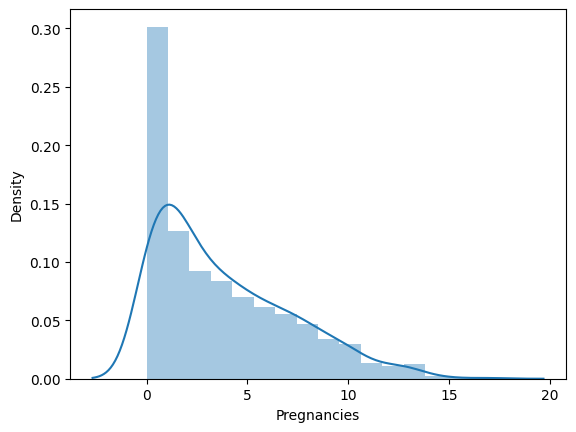

In [12]:
sns.distplot( dataframe["Pregnancies"])

C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\2140232103.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe["BloodPressure"], kde=True)


<Axes: xlabel='BloodPressure', ylabel='Density'>

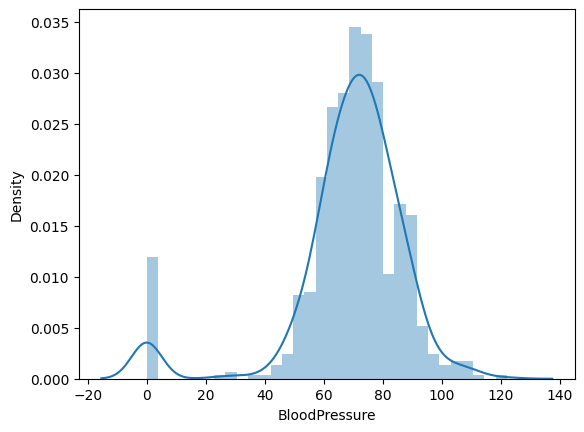

In [13]:
sns.distplot(dataframe["BloodPressure"], kde=True)

C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\71945825.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe["Insulin"], kde=True)


<Axes: xlabel='Insulin', ylabel='Density'>

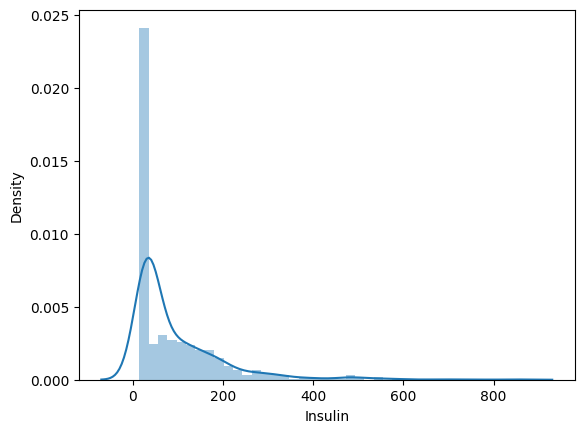

In [63]:
sns.distplot(dataframe["Insulin"], kde=True)

In [15]:
dataframe.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [16]:
# Insulin -> Right skewed distribution, we can replace the 0 values with the median of the column to reduce the skewness and make it more normal.

dataframe["Insulin"] = dataframe["Insulin"].replace(0, dataframe["Insulin"].median())
dataframe["BloodPressure"] = dataframe["BloodPressure"].replace(0, dataframe["BloodPressure"].median())
dataframe["SkinThickness"] = dataframe["SkinThickness"].replace(0, dataframe["SkinThickness"].median())
dataframe["BMI"] = dataframe["BMI"].replace(0, dataframe["BMI"].mean())
dataframe["Glucose"] = dataframe["Glucose"].replace(0, dataframe["Glucose"].mean())
dataframe["Age"] = dataframe["Age"].replace(0, dataframe["Age"].median())
dataframe["Pregnancies"] = dataframe["Pregnancies"].replace(0, dataframe["Pregnancies"].median())
dataframe["DiabetesPedigreeFunction"] = dataframe["DiabetesPedigreeFunction"].replace(0, dataframe["DiabetesPedigreeFunction"].median())


C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\817365903.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe["Glucose"], kde=True)


<Axes: xlabel='Glucose', ylabel='Density'>

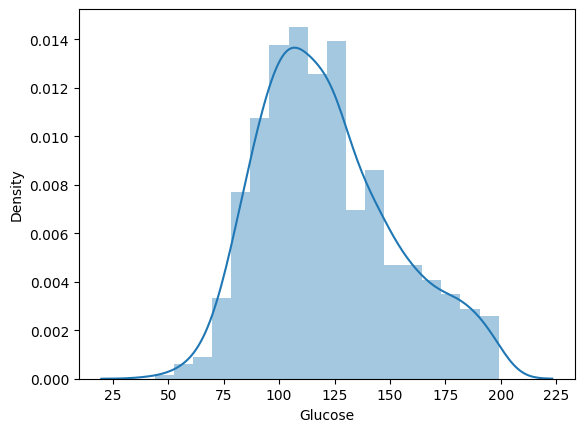

In [17]:
sns.distplot(dataframe["Glucose"], kde=True)

C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\525079288.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe["SkinThickness"], kde=True)


<Axes: xlabel='SkinThickness', ylabel='Density'>

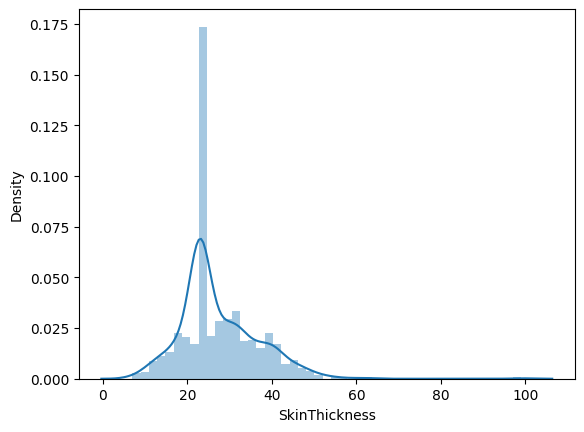

In [18]:
sns.distplot(dataframe["SkinThickness"], kde=True)

C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\2971730781.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe["BMI"], kde=True)


<Axes: xlabel='BMI', ylabel='Density'>

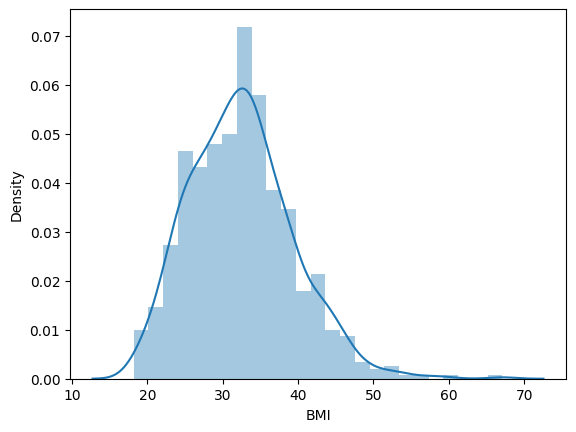

In [19]:
sns.distplot(dataframe["BMI"], kde=True)

C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\2082248986.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe["Age"], kde=True)


<Axes: xlabel='Age', ylabel='Density'>

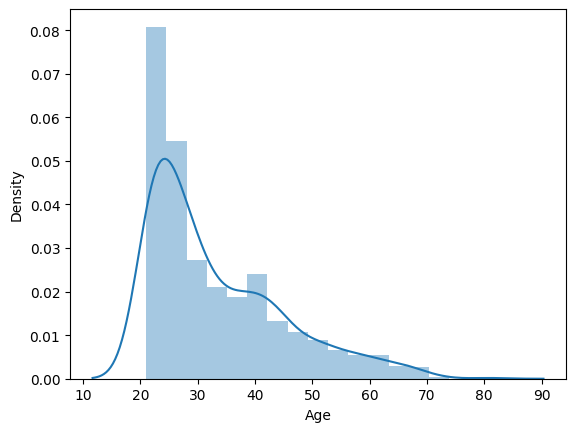

In [20]:

sns.distplot(dataframe["Age"], kde=True)

C:\Users\anujj\AppData\Local\Temp\ipykernel_1336\2151871578.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe["DiabetesPedigreeFunction"], kde=True)


<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Density'>

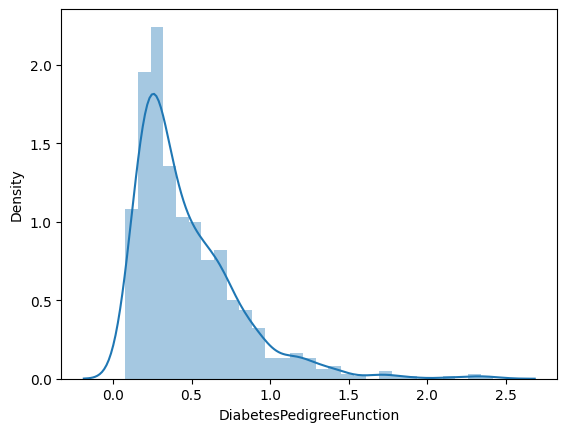

In [21]:
sns.distplot(dataframe["DiabetesPedigreeFunction"], kde=True)

In [22]:
dataframe.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72,35,30.5,33.600000,0.627,50,1
1,1,85.0,66,29,30.5,26.600000,0.351,31,0
2,8,183.0,64,23,30.5,23.300000,0.672,32,1
3,1,89.0,66,23,94.0,28.100000,0.167,21,0
4,3,137.0,40,35,168.0,43.100000,2.288,33,1
5,5,116.0,74,23,30.5,25.600000,0.201,30,0
6,3,78.0,50,32,88.0,31.000000,0.248,26,1
7,10,115.0,72,23,30.5,35.300000,0.134,29,0
8,2,197.0,70,45,543.0,30.500000,0.158,53,1
9,8,125.0,96,23,30.5,31.992578,0.232,54,1


* Descriptive Statistics and it's significance
* Correlation Coefficient and it's significance

* Types of Distribution and it's significance
* Median is more robuts to outliers and why
* Data imputation via Mean and Median [Numeric data]=> Symmetric -> Mean and ,
Skewed-> Median , Categorical -> Mode

In [23]:
x= dataframe.drop("Outcome", axis=1)
y = dataframe["Outcome"]

Outlier Detection => Box plot 

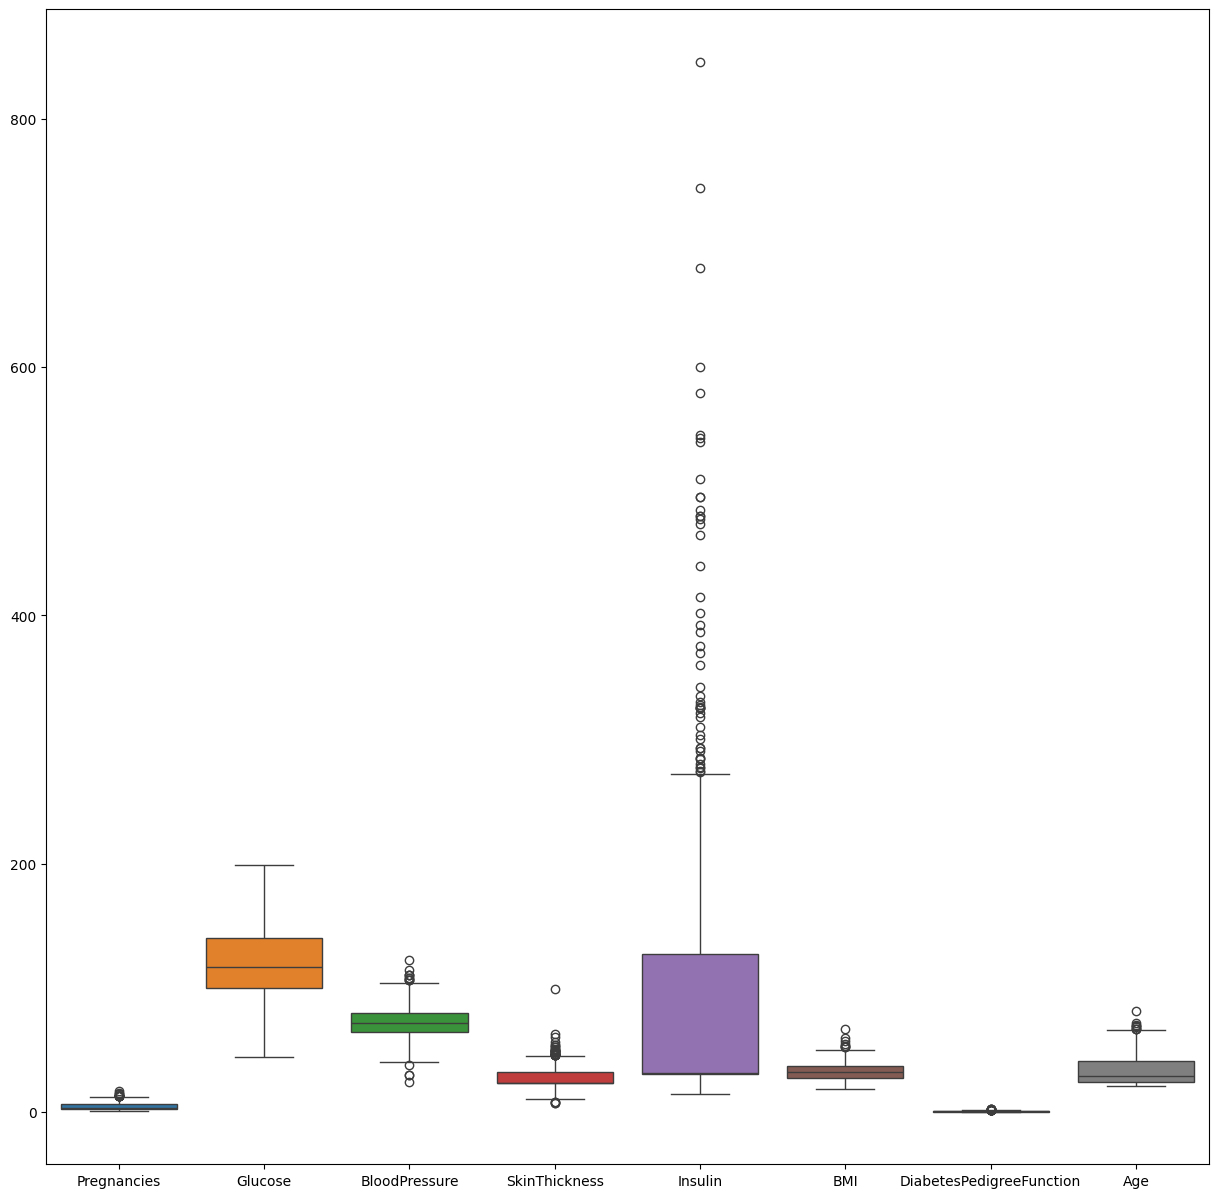

In [24]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=x, ax=ax)
plt.savefig("boxplot.png")
plt.show()

In [25]:
x.shape

(768, 8)

In [26]:
y.shape

(768,)

In [27]:
y.head(20)

0     1
1     0
2     1
3     0
4     1
5     0
6     1
7     0
8     1
9     1
10    0
11    1
12    0
13    1
14    1
15    1
16    1
17    1
18    0
19    1
Name: Outcome, dtype: int64

In [28]:
cols = x.columns
cols

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [29]:
for col in cols:
    q1 = x[col].quantile(0.25)
    q3 = x[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # x[col] = np.where(x[col] < lower_bound, lower_bound, x[col])
    # x[col] = np.where(x[col] > upper_bound, upper_bound, x[col])
    mask = (x[col]>= lower_bound) & (x[col] <= upper_bound)
    

In [30]:
x_outlier_detection = x[mask]
y_outlier_detection = y[mask]

In [31]:
x_outlier_detection.shape

(759, 8)

In [32]:
y_outlier_detection.shape

(759,)

Standardlization or Normalization

Standard normal form  => Mean=0: and dtandard deviation = 1


In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_outlier_detection)

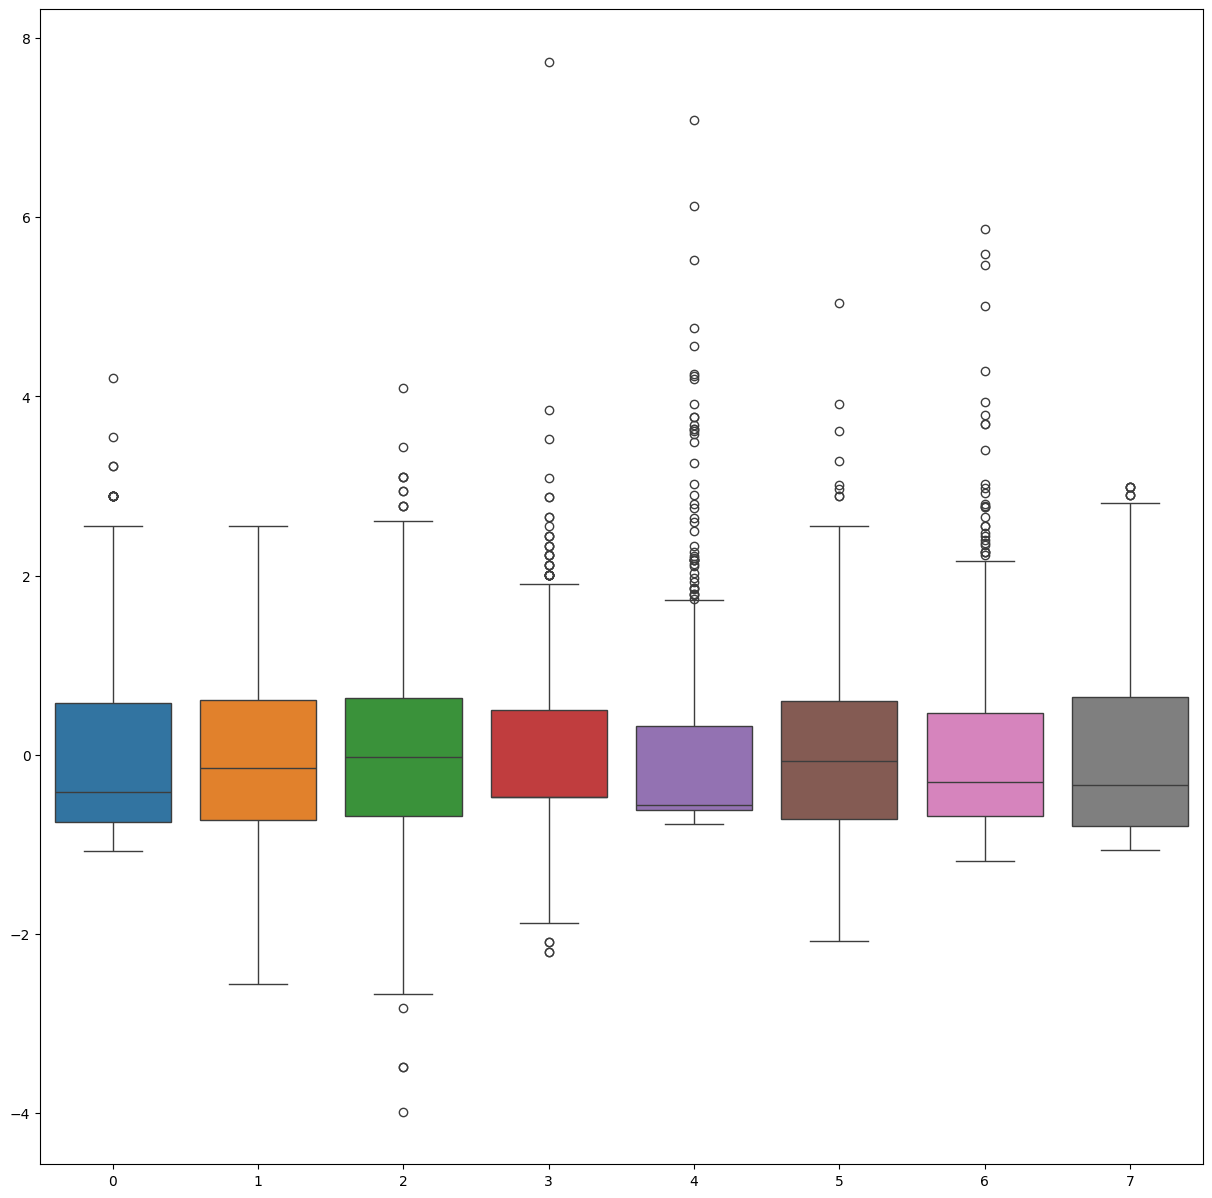

In [34]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=x_scaled, ax=ax)

plt.show()

In [35]:
type (x_scaled)

numpy.ndarray

In [36]:
x_scaled = pd.DataFrame(x_scaled, columns=cols)
x_scaled.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02,7.590000e+02
mean,1.029772e-16,-3.978665e-17,-2.691450e-17,-1.509552e-16,-4.329724e-17,5.546727e-16,4.914821e-17,1.591466e-16
std,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00,1.000659e+00
min,-1.079800e+00,-2.558042e+00,-3.985285e+00,-2.200901e+00,-7.684941e-01,-2.081038e+00,-1.183313e+00,-1.062953e+00
25%,-7.491956e-01,-7.286101e-01,-6.872979e-01,-4.729631e-01,-6.126688e-01,-7.125819e-01,-6.852739e-01,-7.928253e-01
50%,-4.185912e-01,-1.517621e-01,-2.770048e-02,-4.729631e-01,-5.607270e-01,-7.202795e-02,-3.045975e-01,-3.426125e-01
75%,5.732217e-01,6.063810e-01,6.318969e-01,4.990017e-01,3.222827e-01,5.976421e-01,4.627740e-01,6.478556e-01
max,4.209869e+00,2.551183e+00,4.094783e+00,7.734740e+00,7.088876e+00,5.037846e+00,5.864467e+00,2.988962e+00


* Approach 2 of quantiles to remove the outliers
* Handling of imbalance data


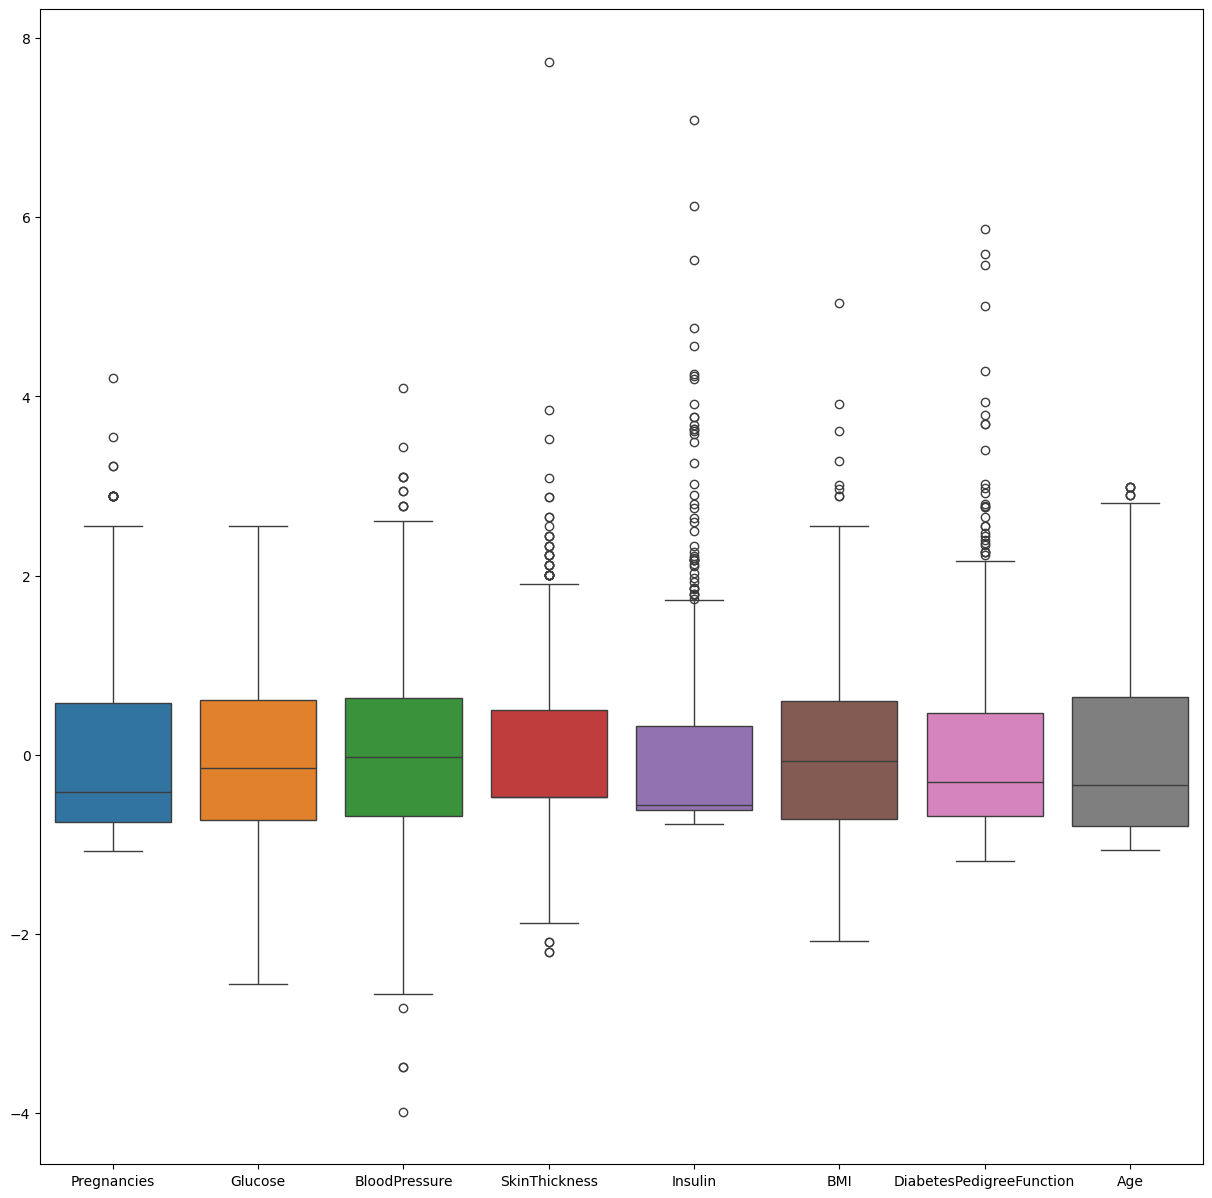

In [37]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=x_scaled, ax=ax)

plt.show()

In [38]:
y_outlier_detection.value_counts()

Outcome
0    493
1    266
Name: count, dtype: int64

# ** Concluding **

# * Detection of the outlier
# * Normalization via StandardScaler form & Why it is important(reduce the biasness in the model)

* Approach 2  :  Quantiles

In [39]:
x_scaled.reset_index(drop=True, inplace=True)
y_outlier_detection.reset_index(drop=True, inplace=True)

In [40]:
q = x_scaled['Insulin'].quantile(0.95)
mask = x_scaled['Insulin'] < q
datanew = x_scaled[mask]
y_outlier_detection = y_outlier_detection[mask]

In [41]:
datanew.shape

(721, 8)

In [42]:
y_outlier_detection.shape

(721,)

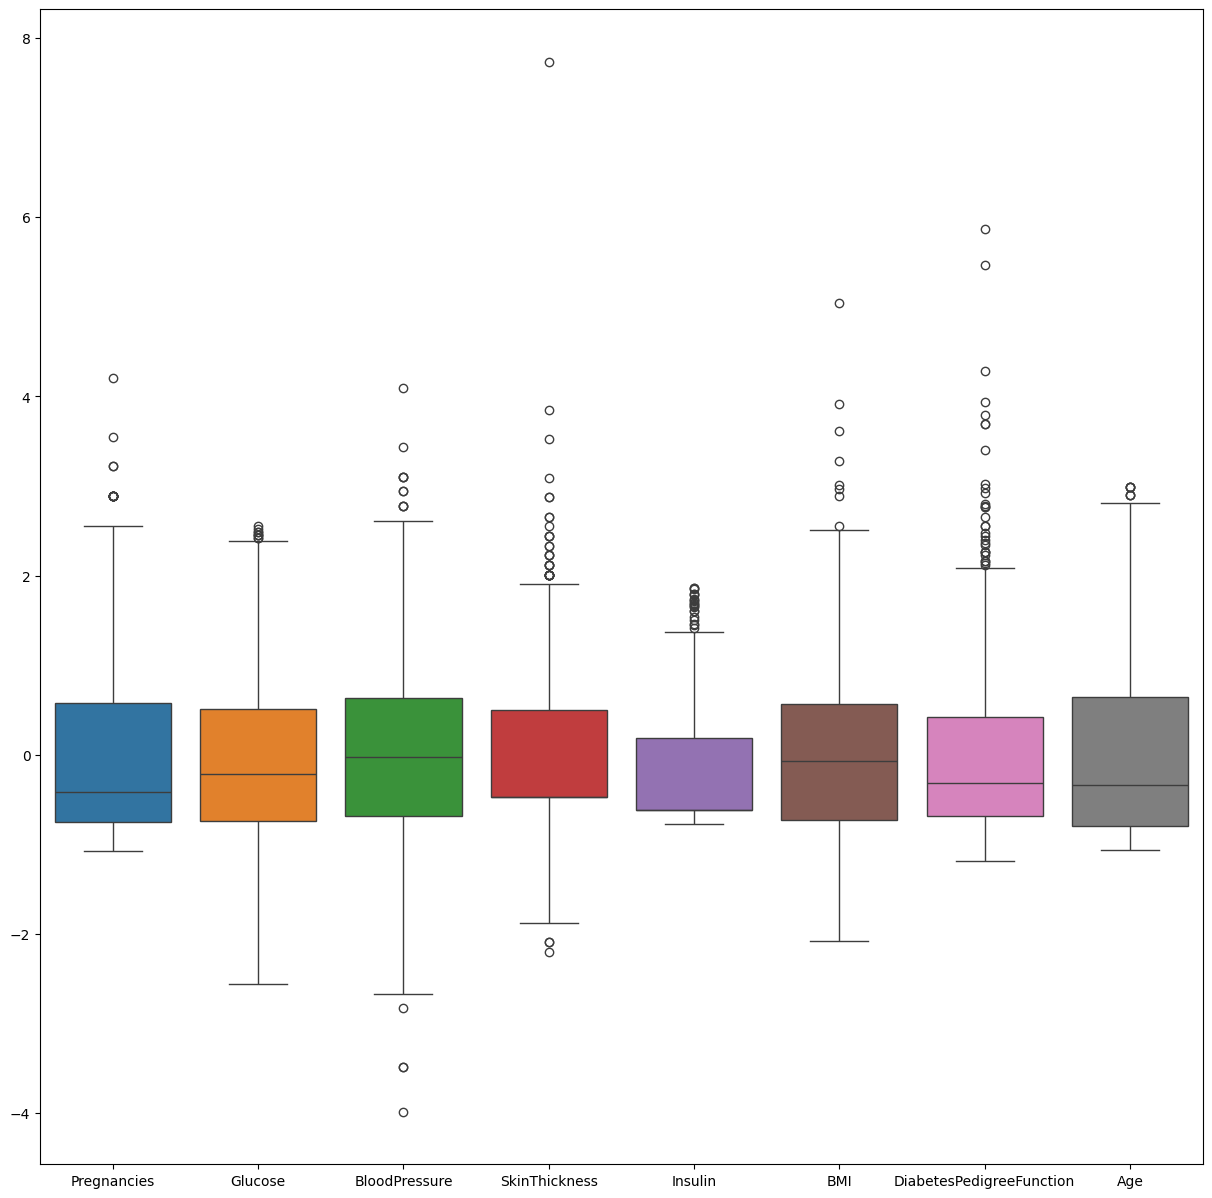

In [43]:
fig,ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=datanew, ax=ax)

plt.show()

Model training

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(datanew, y_outlier_detection, test_size=0.33, random_state=42)

In [45]:
x_train.shape

(483, 8)

In [46]:
x_test.shape

(238, 8)

Dataimbalancig 

* Oversampling : Take Minority Class and Increase that number to the Majority class
* Undersampling : Take Majority Class and Decrease that number to the Minority Class
* SMOTE : Synthetic data and increase the number of samples to the majority class

# link https://imbalanced-learn.org/stable/


In [47]:
y_train.value_counts()

Outcome
0    318
1    165
Name: count, dtype: int64

Smote Technique

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# Check resampled class distribution
print("\n Resampled class distribution:")
print(pd.Series(y_train_resampled).value_counts())


 Resampled class distribution:
Outcome
0    318
1    318
Name: count, dtype: int64


* Model Training
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


In [49]:
from sklearn.linear_model import LogisticRegression

classification = LogisticRegression()
classification.fit(x_train_resampled, y_train_resampled)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


MOdel prediction

In [50]:
y_prediction = classification.predict(x_test)
y_prediction

array([0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

# Model Evaluation

https://scikit-learn.org/stable/api/sklearn.metrics.html

In [51]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_prediction)


0.7521008403361344

* Healthcare : Recall is very Impoprtant in health prediction project

In [52]:
from sklearn.metrics import classification_report
target_names = ['Non-Diabetic', 'Diabetic']
print(classification_report(y_test, y_prediction, target_names=target_names))

              precision    recall  f1-score   support

Non-Diabetic       0.85      0.77      0.81       159
    Diabetic       0.61      0.72      0.66        79

    accuracy                           0.75       238
   macro avg       0.73      0.74      0.73       238
weighted avg       0.77      0.75      0.76       238



In [53]:
import pickle

pickle.dump(classification, open("diabetes_model.pkl", "wb"))

In [54]:
classification_model = pickle.load(open("diabetes_model.pkl", "rb"))

In [55]:
classification_model.predict(x_test)

array([0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

Data Modelling : Implementataion of Naive Bayes Classifier

In [56]:
from sklearn.naive_bayes import GaussianNB
model_gaussian_naive_bayes = GaussianNB()


model_gaussian_naive_bayes.fit(x_train_resampled, y_train_resampled)


,priors,None
,var_smoothing,1e-09


In [57]:
y_predict_gaussian_naive_bayes = model_gaussian_naive_bayes.predict(x_test)
y_predict_gaussian_naive_bayes

array([0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0])

In [58]:
print("confustion matrix for gaussian naive bayes")
from sklearn.metrics import confusion_matrix
cm_gaussian_naive_bayes = confusion_matrix(y_test, y_predict_gaussian_naive_bayes)
print(cm_gaussian_naive_bayes)

confustion matrix for gaussian naive bayes
[[119  40]
 [ 26  53]]


In [65]:
print(classification_report(y_test, y_predict_gaussian_naive_bayes, target_names=target_names))

              precision    recall  f1-score   support

Non-Diabetic       0.82      0.75      0.78       159
    Diabetic       0.57      0.67      0.62        79

    accuracy                           0.72       238
   macro avg       0.70      0.71      0.70       238
weighted avg       0.74      0.72      0.73       238



In [60]:
print(accuracy_score(y_test, y_predict_gaussian_naive_bayes))

0.7226890756302521


* Knn 

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
knn = KNeighborsClassifier()

In [67]:
knn.fit(x_train_resampled, y_train_resampled) 

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


* Model Prediction using knn

In [69]:
y_prediction_knn = knn.predict(x_test)
y_prediction_knn

array([0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [70]:
print("confusion matrix for KNN")
confusion_matrix_knn = confusion_matrix(y_test, y_prediction_knn)
print(confusion_matrix_knn)

confusion matrix for KNN
[[107  52]
 [ 18  61]]


In [72]:
print("classification report")
print(classification_report(y_test, y_prediction_knn, target_names=target_names))

classification report
              precision    recall  f1-score   support

Non-Diabetic       0.86      0.67      0.75       159
    Diabetic       0.54      0.77      0.64        79

    accuracy                           0.71       238
   macro avg       0.70      0.72      0.69       238
weighted avg       0.75      0.71      0.71       238



In [73]:
print("accuracy_score")
print(accuracy_score(y_test, y_prediction_knn))

accuracy_score
0.7058823529411765


In [74]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
knn_regressor = KNeighborsRegressor()

In [75]:
knn_regressor.fit(x_train_resampled, y_train_resampled)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [77]:
y_prediction_knn_regressor = knn_regressor.predict(x_test)
y_prediction_knn_regressor

array([0.2, 0.6, 0.4, 0. , 0.4, 1. , 0. , 0.6, 0.8, 0. , 0.2, 0.6, 0.4,
       0. , 0. , 0. , 0. , 1. , 0.2, 0.2, 0.8, 0.4, 0. , 0.4, 1. , 0.4,
       0.6, 0.4, 0.4, 1. , 0.4, 1. , 1. , 0.8, 0.4, 0.8, 0.2, 0. , 1. ,
       0. , 1. , 0.4, 0.8, 0.6, 0.2, 0. , 0.8, 0.8, 0. , 0. , 0.8, 0. ,
       0.2, 0.2, 0. , 0.2, 0. , 0.6, 1. , 0.4, 0.4, 0.6, 0.6, 0. , 0. ,
       0.6, 0.8, 1. , 0.6, 0.8, 0.6, 0.2, 0.6, 0. , 0.6, 0.4, 1. , 0.8,
       0.2, 0.6, 0.6, 0.2, 0. , 1. , 0. , 0.4, 0.8, 0.2, 1. , 0.2, 0.2,
       1. , 0. , 0.8, 0. , 0. , 0.8, 0. , 1. , 0.4, 0.4, 0.4, 0. , 1. ,
       0.4, 0. , 0.6, 0.6, 0.4, 0.8, 0.8, 0.2, 0. , 1. , 1. , 0. , 0.6,
       0. , 0. , 0. , 0.2, 1. , 0.6, 0.2, 0.4, 0. , 0. , 0. , 0. , 0. ,
       0.4, 0. , 1. , 0.8, 0. , 0.8, 0. , 0.4, 0.6, 0.2, 0.4, 0.8, 0.4,
       0. , 0. , 0.8, 0.2, 1. , 1. , 0.4, 0.8, 0.4, 0. , 1. , 0.4, 0.6,
       1. , 0.6, 0.8, 0. , 0. , 0.8, 1. , 0.6, 0.6, 1. , 0.2, 0.8, 0. ,
       0. , 0.6, 0. , 0. , 0. , 0. , 1. , 0.8, 0.6, 0.8, 1. , 0.

In [78]:
print("confusion matrix for KNN")
confusion_matrix_knn = confusion_matrix(y_test, y_prediction_knn_regressor.round())
print(confusion_matrix_knn)

confusion matrix for KNN
[[107  52]
 [ 18  61]]


In [79]:
print("accuracy_score")
print(accuracy_score(y_test, y_prediction_knn_regressor.round()))

accuracy_score
0.7058823529411765
